# SDR Lab: Noise Analysis and FM Reception
**Duration:** 2 hours  
**Date:** August 2025

**Getting started link:** https://pysdr.org/content/pluto.html

## Learning Objectives:
1. Understand complex signal representation in SDR
2. Analyze noise characteristics empirically
3. Implement FM demodulation
4. Work with time and frequency domain representations

---
**About this version:** this notebook is the main lab. The TODO cells below include extra
*hint comments* drawn from two other sources so students have more to work from:
- an earlier, simpler introductory draft of this lab, and
- `fm_radio.py`, a polished, production-style real-time FM receiver script.

These are comments only — the TODOs are still yours to complete. Some hints point out a
simpler alternative approach; others point out a production-quality trick (persistent filter
state, de-emphasis filtering, non-blocking audio streaming, etc.) that goes beyond what's
strictly required for the lab but is good to know about.

In [17]:
# Install required packages
!pip install matplotlib numpy scipy sounddevice

In [18]:
import numpy as np
import adi
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import resample
import sounddevice as sd
import time

# Configure PlutoSDR
sample_rate = 1e6 # Hz
center_freq = 400e6 # Hz (empty-spectrum baseline for noise analysis; we retune for FM later)
num_samps = 100000 # number of samples returned per call to rx()

# NOTE: update this IP to match your actual Pluto device.
# Different drafts/scripts in this lab series have used 192.168.2.1, 192.168.2.7, and
# 192.168.3.1 - check your Pluto's USB/network config if you're not sure which is yours.
sdr = adi.Pluto('ip:192.168.2.1')

# Gain: this lab uses manual gain so power readings are directly comparable across frequencies.
# For a *deployed* receiver (see fm_radio.py) you'd typically use AGC instead:
#   sdr.gain_control_mode_chan0 = 'slow_attack'
# which continuously adjusts gain for you - convenient for long unattended playback, but
# less useful here since we want repeatable measurements between bands.
sdr.gain_control_mode_chan0 = 'manual'
sdr.rx_hardwaregain_chan0 = 70.0 # dB
sdr.rx_lo = int(center_freq)
sdr.sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(sample_rate) # filter width, just set it to the same as sample rate for now
sdr.rx_buffer_size = num_samps

# Optional (from fm_radio.py): flush a few buffers right after (re)configuring the SDR.
# The first few rx() calls after retuning can contain stale/settling samples.
# for _ in range(10):
#     _ = sdr.rx()

print("PlutoSDR configured successfully!")

PlutoSDR configured successfully!


# Part 1: Receiving and Analyzing Noise  

First, let's receive some samples and understand what we're getting from the SDR.

In [19]:
# Receive initial samples
samples = sdr.rx() # receive samples off Pluto
print(f"Received {len(samples)} samples")
print(f"First 10 samples: {samples[:10]}")
print(f"Sample data type: {samples.dtype}")

Received 100000 samples
First 10 samples: [ -3. +7.j  14. -5.j -19. -5.j   1. -6.j -17. +4.j  11. +6.j  20.-21.j
   6. +1.j   5.+11.j  -1.+19.j]
Sample data type: complex128


## Task 1: Collect More Samples  
Put the `samples = sdr.rx()` in a loop and collect more samples. Store them in a variable called `more_samples`. Collect at least 5 iterations worth of samples.

In [20]:
# Task 1: Your code here
# Collect multiple batches of samples
more_samples = []
# TODO: Write a loop to collect 5 batches of samples

# Hint (from the intro lab draft): the simplest version of this loop is
for _ in range(5):
    batch = sdr.rx()
    more_samples.append(batch)


# sdr.rx() already returns a numpy array each call, so once you're done collecting,
# np.concatenate(more_samples) is usually cleaner than converting a list of arrays
# directly with np.array(more_samples).
# Convert to numpy array for easier processing

more_samples = np.concatenate(more_samples)
print(f"Total samples collected: {len(more_samples)}")

Total samples collected: 500000


## Task 2: Scatter Plot Analysis  
Create a scatter plot of the real vs imaginary parts of your samples. This is called a "constellation diagram" in communications.

**Your task:** Plot np.real(more_samples) vs np.imag(more_samples) using plt.scatter(). Use only the first 10,000 samples for clarity.

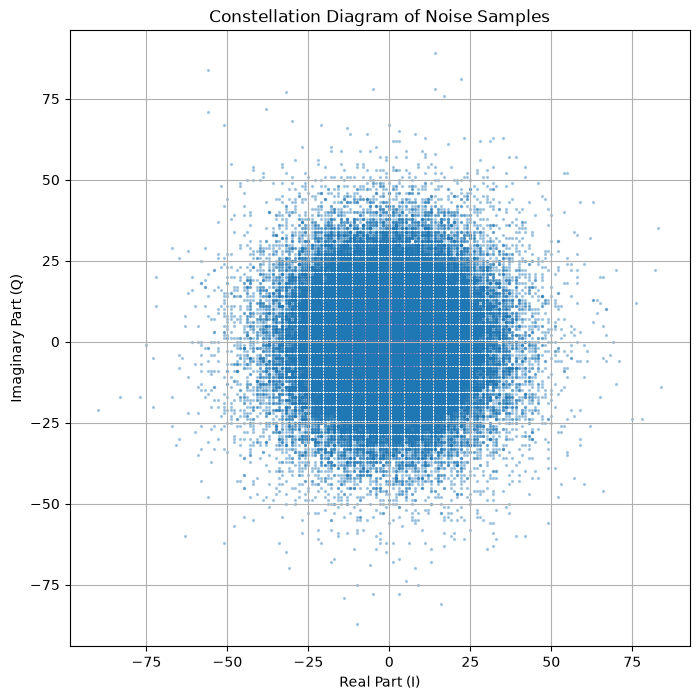

In [5]:
# Task 2: Create scatter plot here
# Extract real and imaginary parts

real_part = np.real(more_samples)
imag_part = np.imag(more_samples)

# TODO: Create scatter plot of real vs imaginary parts
# - Use plt.figure() to set the figure size to (8, 8)

plt.figure(figsize=(8, 8))

# - Create a scatter plot of real_part vs imag_part (first 100000 samples)

plt.scatter(real_part[:100000], imag_part[:100000], s=2, alpha=0.3)

# - Set appropriate title, xlabel, ylabel

plt.title("Constellation Diagram of Noise Samples")
plt.xlabel("Real Part (I)")
plt.ylabel("Imaginary Part (Q)")

# - Add grid and ensure equal axis scaling

plt.grid(True)
plt.axis('equal')

# - Display the plot

plt.show()

# Hint: with this many points, plt.scatter(..., s=2, alpha=0.3) reads much better than the
# default marker size/opacity - a big solid blob won't show you the shape of the noise cloud.
# e.g.: plt.scatter(real_part[:10000], imag_part[:10000], s=2, alpha=0.3)
# plt.axis('equal')   # keeps the constellation circular instead of stretched

## Task 3: Histogram Analysis
Plot histograms of the real and imaginary parts separately. Then analyze their statistical distributions.

**Your task:**
1. Create histograms of real_part and imag_part using plt.hist()
2. Fit Gaussian distributions using stats.norm.fit()
3. Overlay the fitted distributions on your histograms

Real Part: mu = -0.0136, sigma = 14.3737
Imaginary Part: mu = -0.0487, sigma = 14.3766


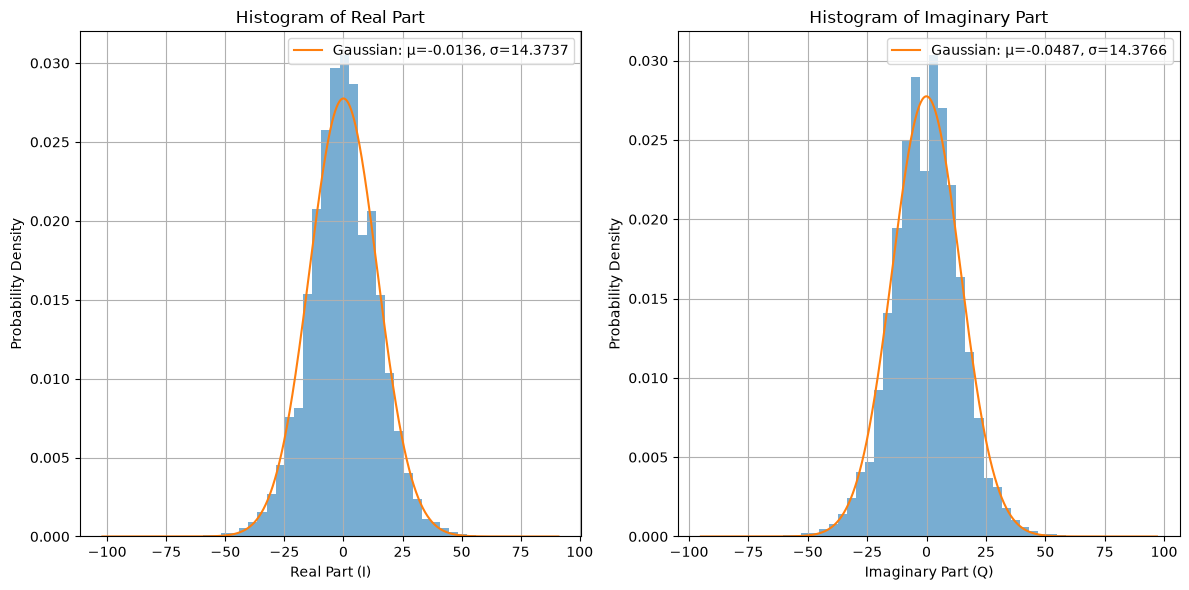

In [7]:
# Task 3: Histogram analysis with distribution fitting

# Extract real and imaginary parts

real_part = np.real(more_samples)
imag_part = np.imag(more_samples)

# TODO: Create side-by-side histograms for real and imaginary parts

# Hint: Use plt.figure() with figsize=(12, 6) and plt.subplot(1, 2, 1) for left plot

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(real_part, bins=50, density=True, alpha=0.6)
plt.title("Histogram of Real Part")
plt.xlabel("Real Part (I)")
plt.ylabel("Probability Density")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(imag_part, bins=50, density=True, alpha=0.6)
plt.title("Histogram of Imaginary Part")
plt.xlabel("Imaginary Part (Q)")
plt.ylabel("Probability Density")
plt.grid(True)

# TODO: Fit Gaussian distributions to both real and imaginary parts

# Hint: Use stats.norm.fit(data) which returns (mu, sigma)

mu_real, sigma_real = stats.norm.fit(real_part)
mu_imag, sigma_imag = stats.norm.fit(imag_part)

print(f"Real Part: mu = {mu_real:.4f}, sigma = {sigma_real:.4f}")
print(f"Imaginary Part: mu = {mu_imag:.4f}, sigma = {sigma_imag:.4f}")

# TODO: Plot the fitted Gaussian curves over the histograms

# Hint: Create x values using np.linspace() and calculate PDF using stats.norm.pdf()

x_real = np.linspace(np.min(real_part), np.max(real_part), 1000)
x_imag = np.linspace(np.min(imag_part), np.max(imag_part), 1000)

pdf_real = stats.norm.pdf(x_real, mu_real, sigma_real)
pdf_imag = stats.norm.pdf(x_imag, mu_imag, sigma_imag)

# Add the curves to both subplots with appropriate labels showing mu and sigma values

plt.subplot(1, 2, 1)
plt.plot(x_real, pdf_real,
         label=f"Gaussian: μ={mu_real:.4f}, σ={sigma_real:.4f}")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_imag, pdf_imag,
         label=f"Gaussian: μ={mu_imag:.4f}, σ={sigma_imag:.4f}")
plt.legend()

# Extra hint: plt.hist(..., density=True) is what lets you overlay a PDF directly - without

# density=True the histogram counts and the Gaussian PDF end up on different y-scales.

plt.tight_layout()
plt.show()

## Task 4: Analysis Questions (10 minutes)
Based on your plots and statistical analysis above, answer these questions:

1. **What distribution do the real and imaginary parts follow?**
   - Looking at the histograms and statistical fits, what can you conclude?

2. **What does the constellation diagram tell us?**
   - Is there any structure or is it random?

3. **Are the real and imaginary parts correlated?**
   - Do they appear to be independent?

**Expected observations:**
- The data should show characteristics of **complex Gaussian noise** (AWGN - Additive White Gaussian Noise)
- Both I and Q components should be approximately Gaussian with similar variances
- The constellation should appear as a circular cloud centered around the origin
- This is what we expect when receiving thermal noise

## Task 5: Frequency Analysis (5 minutes)
Try different frequencies to find where you receive only noise vs actual signals.

**Your task:** Test these frequencies and compare their power spectra:
- 88 MHz (Low end of FM band)
- 95 MHz (Mid FM band)
- 103 MHz (Your original frequency)
- 108 MHz (High end of FM band)
- 400 MHz (Empty spectrum area)

Frequency: 88 MHz, Max Power: 18.3 dBm/Hz, Avg Noise Floor: -3.5 dBm/Hz
Frequency: 95 MHz, Max Power: 18.3 dBm/Hz, Avg Noise Floor: -5.3 dBm/Hz
Frequency: 103 MHz, Max Power: 18.1 dBm/Hz, Avg Noise Floor: -6.0 dBm/Hz
Frequency: 108 MHz, Max Power: 28.8 dBm/Hz, Avg Noise Floor: 0.4 dBm/Hz
Frequency: 400 MHz, Max Power: 29.0 dBm/Hz, Avg Noise Floor: -0.2 dBm/Hz


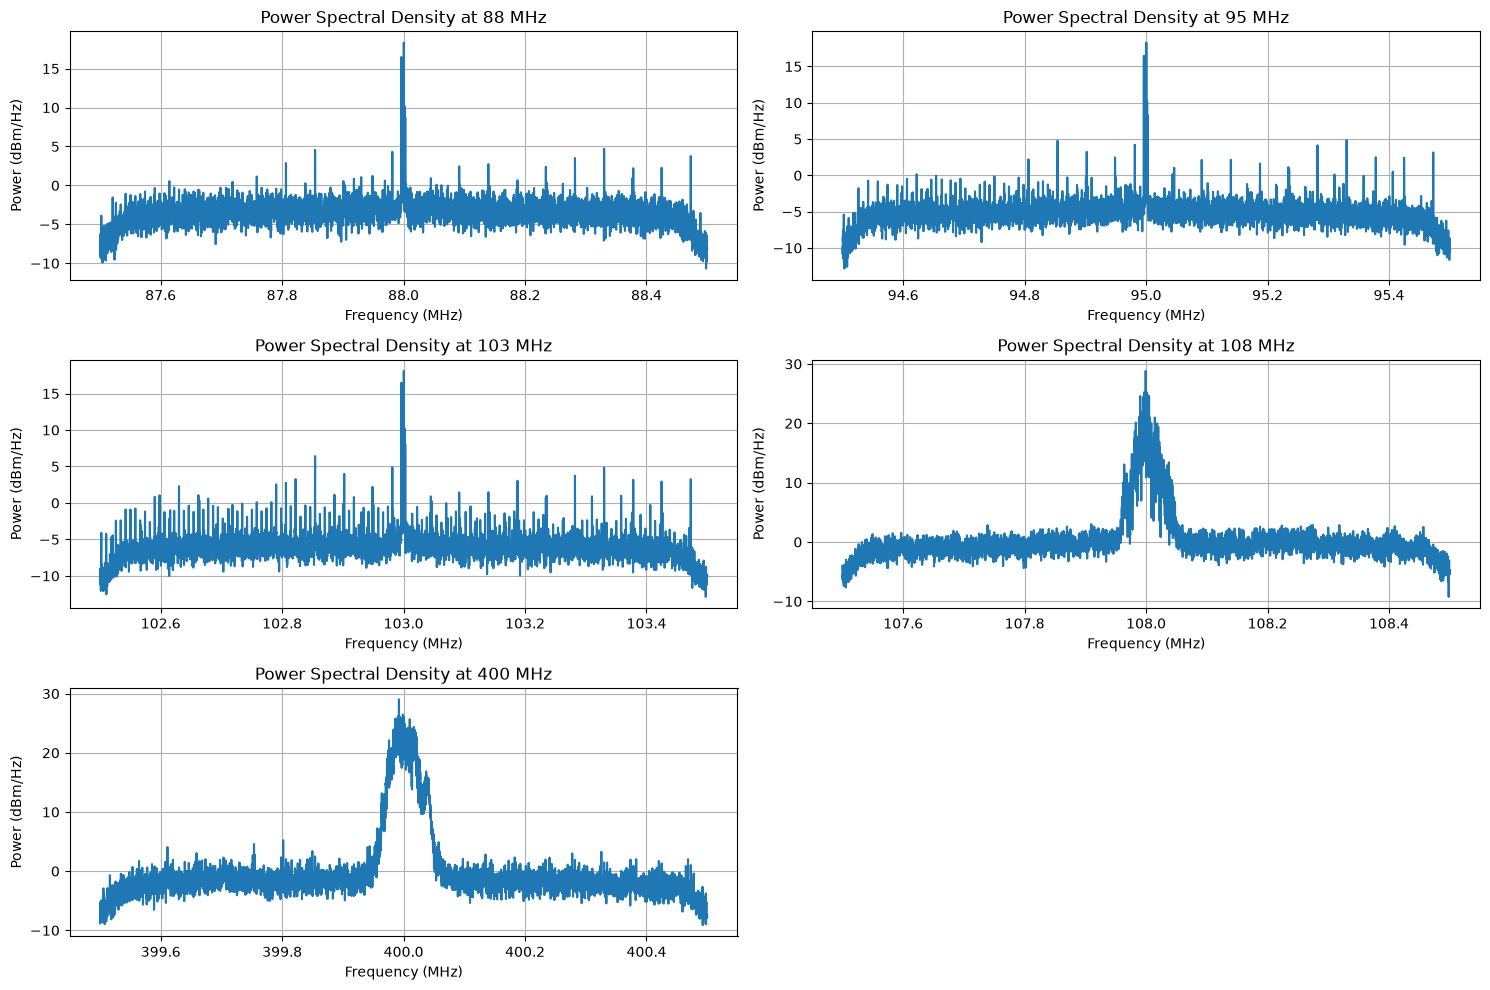

Reset to original frequency: 400.0 MHz

Note: Using Welch's method for better PSD estimation with averaging and windowing


In [21]:
# Task 5: Test different frequencies
test_frequencies = [88e6, 95e6, 103e6, 108e6, 400e6]

# Import scipy for PSD functions
from scipy import signal

# Create figure for subplots
plt.figure(figsize=(15, 10))

# Loop through each frequency and analyze the signal
for i, freq in enumerate(test_frequencies):
    # Set the SDR receiver frequency
    sdr.rx_lo = int(freq)

    # Collect samples
    samples = sdr.rx()

    # Calculate PSD using Welch's method (much better than manual FFT)
    freqs_psd, psd = signal.welch(samples, fs=sample_rate,
                                  window='hann', nperseg=8192,
                                  return_onesided=False, scaling='density')

    # Shift to center the spectrum
    freqs_shifted = np.fft.fftshift(freqs_psd)
    psd_shifted = np.fft.fftshift(psd)

    # Convert to actual frequencies (add center frequency)
    actual_freqs = freqs_shifted + freq

    # Convert to dBm/Hz
    psd_dbm = 10 * np.log10(psd_shifted + 1e-20) + 30

    # Create subplot
    plt.subplot(3, 2, i+1)
    plt.plot(actual_freqs/1e6, psd_dbm)
    plt.title(f'Power Spectral Density at {freq/1e6:.0f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Power (dBm/Hz)')
    plt.grid(True)

    # Print statistics
    max_power_dbm = np.max(psd_dbm)
    avg_noise_floor = np.mean(psd_dbm)
    print(f"Frequency: {freq/1e6:.0f} MHz, Max Power: {max_power_dbm:.1f} dBm/Hz, Avg Noise Floor: {avg_noise_floor:.1f} dBm/Hz")

plt.tight_layout()
plt.show()

# Reset to original frequency
sdr.rx_lo = int(center_freq)
print(f"Reset to original frequency: {center_freq/1e6:.1f} MHz")
print("\nNote: Using Welch's method for better PSD estimation with averaging and windowing")

# Hint for interpretation: watch for one test frequency with a noticeably higher max power
# AND a raised noise floor compared to the others - that's a real signal, not just noise.
# (In an earlier run of this exact sweep, 108 MHz stood out this way - worth checking whether
# that holds at your location too.)

# Part 2: FM Radio Reception and Demodulation (75 minutes)

## Setup Audio System

In [22]:
# Test audio system
print("Available audio devices:")
print(sd.query_devices())

# Test with a simple tone
print("\nTesting audio system with 1kHz tone for 1 second...")
test_tone = np.sin(2 * np.pi * 1000 * np.linspace(0, 1, 44100))
try:
    sd.play(test_tone, samplerate=44100)
    sd.wait()  # Wait until the sound finishes playing
    print("Audio test successful!")
except Exception as e:
    print(f"Audio test failed: {e}")
    print("You may not hear audio, but demodulation analysis will still work.")

Available audio devices:
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Speaker (Realtek(R) Audio), MME (0 in, 2 out)
   4 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   5 Microphone Array (Intel® Smart Sound Technology for Digital Microphones), Windows DirectSound (4 in, 0 out)
   6 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   7 Speaker (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
   8 Speaker (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
   9 Microphone Array (Intel® Smart Sound Technology for Digital Microphones), Windows WASAPI (2 in, 0 out)
  10 Headphones (), Windows WDM-KS (0 in, 2 out)
  11 Microphone Array 1 (), Windows WDM-KS (2 in, 0 out)
  12 Microphone Array 2 (), Windows WDM-KS (2 in, 0 out)
  13 Microphone Array 3 (), Windows WDM-KS (4 in, 0 out)
  14 Headphones (), Windows WDM-KS (0 in, 2 out)
  15 Ste

## Task 6: Implement FM Demodulation (30 minutes)

Receiving FM samples...
Received 100000 samples

Step 1: Extracting instantaneous phase...
Phase range: -3.130 to 3.142 radians

Step 2: Unwrapping phase...
Unwrapped phase range: -1153.102 to 24.584 radians

Step 3: Computing derivative (instantaneous frequency)...
Instantaneous frequency in Hz: -500000.0 to 500000.0 Hz


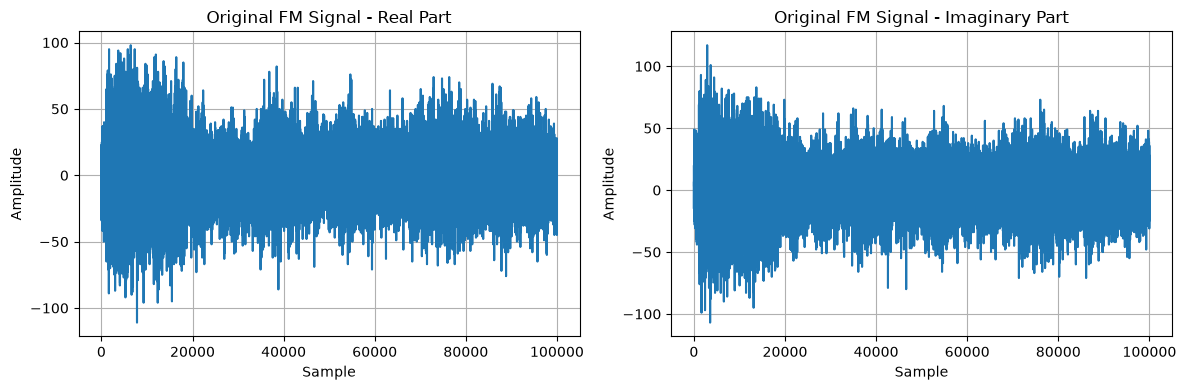

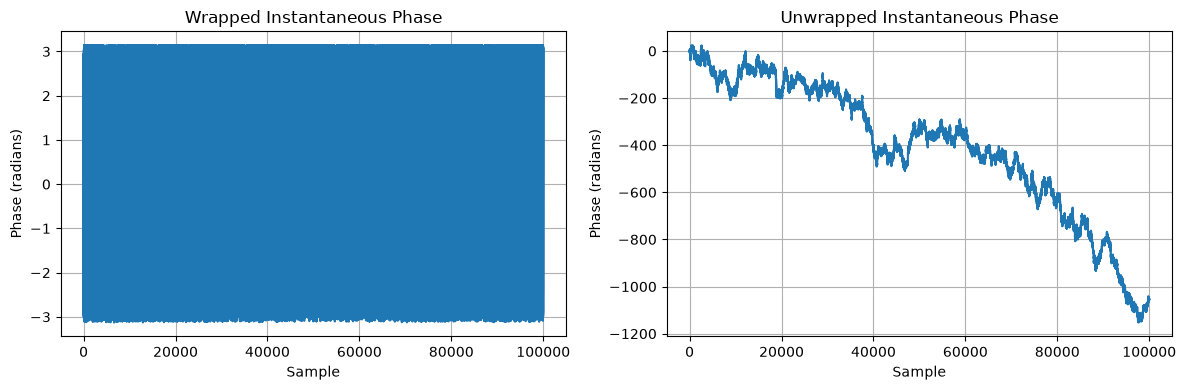

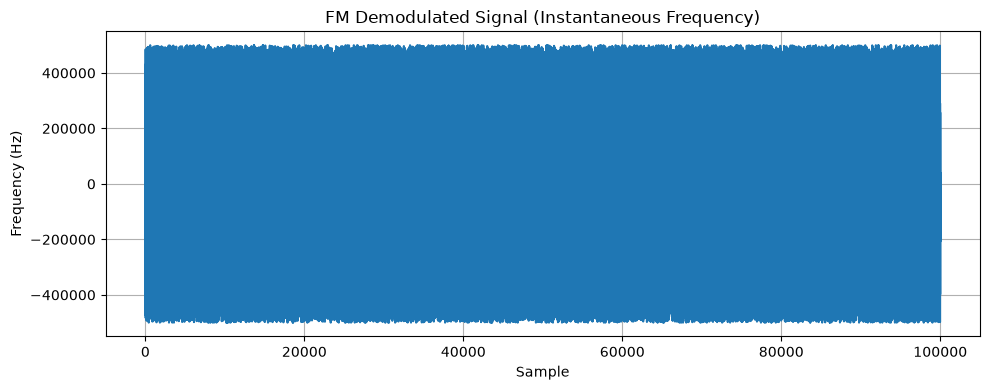

In [23]:
# Task 6: Step-by-step FM demodulation implementation
# First, let's receive some samples at FM frequency

print("Receiving FM samples...")
fm_samples = sdr.rx()
print(f"Received {len(fm_samples)} samples")

# Step 1: Extract the instantaneous phase
print("\nStep 1: Extracting instantaneous phase...")

# TODO: Complete this line - extract phase using np.angle()
instantaneous_phase = np.angle(fm_samples)  # e.g. np.angle(fm_samples)
print(f"Phase range: {np.min(instantaneous_phase):.3f} to {np.max(instantaneous_phase):.3f} radians")

# Step 2: Unwrap the phase to handle discontinuities
print("\nStep 2: Unwrapping phase...")

# TODO: Complete this line - unwrap phase using np.unwrap()
unwrapped_phase = np.unwrap(instantaneous_phase)  # e.g. np.unwrap(instantaneous_phase)
print(f"Unwrapped phase range: {np.min(unwrapped_phase):.3f} to {np.max(unwrapped_phase):.3f} radians")

# Step 3: Take the derivative to get instantaneous frequency
print("\nStep 3: Computing derivative (instantaneous frequency)...")

# TODO: Complete this line - take the derivative using np.diff()
instantaneous_frequency = np.diff(unwrapped_phase)  # e.g. np.diff(unwrapped_phase)

# Convert from radians per sample to Hz
instantaneous_message = instantaneous_frequency * sample_rate / (2 * np.pi)
print(f"Instantaneous frequency in Hz: {np.min(instantaneous_message):.1f} to {np.max(instantaneous_message):.1f} Hz")

# Hint: there's a one-line shortcut for Steps 1-3 combined, used in the intro lab draft and in
# fm_radio.py - multiplying each sample by the complex conjugate of the previous one folds the
# phase difference into a single np.angle() call, with no separate unwrap/diff step needed:
# demod = np.angle(fm_samples[1:] * np.conj(fm_samples[:-1]))
# Implementing Steps 1-3 explicitly first is worth doing so you understand *why* that shortcut
# works (phase unwrapping is exactly what's needed when consecutive phases jump across the
# +-pi boundary) - the two approaches should give equivalent results, which is a good way to
# check your work.

# TODO: Create plots to visualize each step of the process
# Plot 1: Original signal (real and imaginary parts)
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot real part, Right: plot imaginary part
# - Add appropriate titles and labels

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.real(fm_samples))
plt.title("Original FM Signal - Real Part")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(np.imag(fm_samples))
plt.title("Original FM Signal - Imaginary Part")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 2: Instantaneous phase (wrapped and unwrapped)
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot wrapped phase, Right: plot unwrapped phase
# - Add appropriate titles and labels

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(instantaneous_phase)
plt.title("Wrapped Instantaneous Phase")
plt.xlabel("Sample")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(unwrapped_phase)
plt.title("Unwrapped Instantaneous Phase")
plt.xlabel("Sample")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 3: Demodulated signal (instantaneous frequency)
# - Create figure with size (10, 4)
# - Plot the instantaneous_message
# - Add title, labels, and grid

plt.figure(figsize=(10, 4))
plt.plot(instantaneous_message)
plt.title("FM Demodulated Signal (Instantaneous Frequency)")
plt.xlabel("Sample")
plt.ylabel("Frequency (Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 7: Audio Processing and Playback (25 minutes)
Now let's process the demodulated signal for audio playback.

**Your task:**
1. Remove DC component from the demodulated signal
2. Resample from 1 MHz to 44.1 kHz using `resample()`
3. Normalize the signal for audio playback
4. Play the audio using `sd.play()`

> **Note:** there isn't a separate code cell for this task - you'll implement it as the
> `audio_processing_function()` inside the Task 8 cell below, since in a real-time receiver
> audio processing has to happen as part of the same per-chunk loop as demodulation.
> For reference, `fm_radio.py` also folds a 15 kHz low-pass filter and a 75us de-emphasis
> filter into this stage - not required here, but worth knowing about if your demodulated
> audio sounds harsher/hissier than a real FM receiver.

## Task 8: Real-time FM Demodulation (20 minutes)
Let's create a real-time version that continuously demodulates FM radio.

**Your task:** Complete the FM demodulation function and run it in a loop for real-time processing.

In [24]:
# Task 8: Real-time FM demodulation
print("Starting real-time FM demodulation...")
print("This will run for 30 seconds. Press Ctrl+C to stop early.")

# ============================================================
# Additional configuration for real-time FM receiver
# ============================================================

# Tune PlutoSDR to an FM broadcast station
center_freq = 98.3e6
sdr.rx_lo = int(center_freq)

# Audio sample rate
playback_sample_rate = 44100

# FM broadcast audio bandwidth
audio_cutoff = 15000

# Low-pass filter for recovered audio
from scipy.signal import butter, sosfilt, resample_poly

sos = butter(
    6,
    audio_cutoff,
    btype="lowpass",
    fs=sample_rate,
    output="sos"
)

# Filter state so that the filter remains continuous between chunks
sos_state = np.zeros((sos.shape[0], 2))

# Previous IQ sample for phase continuity
previous_sample = None


def fm_demodulation_function(samples, last_phase):
    """Complete the FM demodulation function"""

    global previous_sample

    # Make sure samples are complex
    samples = np.asarray(samples, dtype=np.complex64)

    # --------------------------------------------------------
    # Remove DC offset
    # --------------------------------------------------------
    samples = samples - np.mean(samples)

    # --------------------------------------------------------
    # Normalize IQ amplitude
    # --------------------------------------------------------
    magnitude = np.abs(samples)

    samples = samples / (
        np.mean(magnitude) + 1e-12
    )

    # --------------------------------------------------------
    # Preserve phase continuity between Pluto buffers
    # --------------------------------------------------------
    if previous_sample is not None:
        samples = np.concatenate(
            ([previous_sample], samples)
        )

    # Save last sample for next iteration
    previous_sample = samples[-1]

    # --------------------------------------------------------
    # FM demodulation
    #
    # phase difference:
    # angle(x[n] * conj(x[n-1]))
    # --------------------------------------------------------

    # Step 1: Extract phase using np.angle()
    phase = np.angle(
        samples[1:] * np.conj(samples[:-1])
    )

    # Step 2: Unwrap phase, incorporating last phase for continuity
    # Hint: Concatenate last_phase with current phase, unwrap, then remove first element
    #   e.g. unwrapped_phase = np.unwrap(np.concatenate(([last_phase], phase)))[1:]

    # The phase-difference method already gives the phase change
    # directly in the range [-pi, pi], so explicit unwrapping is
    # not required here.
    unwrapped_phase = phase

    # Step 3: Differentiate to get instantaneous frequency using np.diff()
    inst_message = unwrapped_phase

    # TODO: Convert from radians/sample to Hz
    # Multiply by sample_rate/(2*pi)
    inst_message_hz = (
        inst_message * sample_rate / (2 * np.pi)
    )

    # Return both demodulated signal and the last phase value for next iteration
    return inst_message_hz, unwrapped_phase[-1]


def audio_processing_function(demod_signal, target_length):
    """Process demodulated signal for audio playback"""

    global sos_state

    # --------------------------------------------------------
    # Low-pass filter recovered FM audio
    # --------------------------------------------------------
    demod_signal, sos_state = sosfilt(
        sos,
        demod_signal,
        zi=sos_state
    )

    # --------------------------------------------------------
    # Remove DC component
    # --------------------------------------------------------
    demod_signal = demod_signal - np.mean(demod_signal)

    # Step 1: Resample to audio rate using resample()

    # Use polyphase resampling:
    # 1 MHz -> 44.1 kHz
    #
    # 44100 / 1000000 = 441 / 10000
    audio_signal = resample_poly(
        demod_signal,
        441,
        10000
    )

    # Make sure the output has approximately the requested length
    if len(audio_signal) > target_length:
        audio_signal = audio_signal[:target_length]

    elif len(audio_signal) < target_length:
        audio_signal = np.pad(
            audio_signal,
            (0, target_length - len(audio_signal))
        )

    # Remove DC again after resampling
    audio_signal = audio_signal - np.mean(audio_signal)

    # Step 2: Normalize audio
    # Check if signal has any amplitude, then normalize to prevent clipping
    if np.max(np.abs(audio_signal)) > 0:
        # TODO: Normalize and apply volume reduction (multiply by 0.3)
        # Hint: fm_radio.py does this as (audio / np.max(np.abs(audio))) * 0.8 - scaling by
        # the max absolute value first prevents clipping regardless of how loud the raw
        # demodulated signal happens to be. (This lab's target headroom is a bit more
        # conservative at 0.3.)
        normalized_audio = (
            audio_signal / np.max(np.abs(audio_signal))
        ) * 0.3

    else:
        normalized_audio = audio_signal

    return normalized_audio.astype(np.float32)


# ============================================================
# Persistent audio output stream
# ============================================================

audio_stream = sd.OutputStream(
    samplerate=playback_sample_rate,
    channels=1,
    dtype="float32",
    blocksize=0
)

audio_stream.start()

print(f"FM frequency : {center_freq / 1e6:.2f} MHz")
print(f"Sample rate  : {sample_rate / 1e6:.1f} MHz")
print(f"Audio rate   : {playback_sample_rate} Hz")
print("Audio output started.")
print("You should now hear the FM station if it is received.")


# Real-time processing loop
try:
    start_time = time.time()
    chunk_count = 0

    # TODO: Initialize phase tracking variable for continuity across chunks
    # Hint: this just needs a valid starting phase for the very first chunk, e.g. 0.0
    last_sample_phase = 0.0

    while time.time() - start_time < 30:  # Run for 30 seconds

        # TODO: Receive samples from SDR
        samples = sdr.rx()

        # TODO: Demodulate using your function
        # Should return (demodulated_signal, last_phase)
        # e.g. demodulated, last_sample_phase = fm_demodulation_function(samples, last_sample_phase)
        demodulated, last_sample_phase = fm_demodulation_function(
            samples,
            last_sample_phase
        )

        # Calculate target audio length
        # Convert from SDR sample rate to audio sample rate
        audio_length = int(
            len(demodulated)
            * playback_sample_rate
            / sample_rate
        )

        # Skip if no audio samples to process
        if audio_length == 0:
            continue

        # Process demodulated signal for audio playback
        audio_chunk = audio_processing_function(
            demodulated,
            audio_length
        )

        # TODO: Play audio chunk (non-blocking)
        # Use sd.play() with samplerate=playback_sample_rate, blocking=False
        # Hint: calling sd.play() fresh for every chunk (as this stub does) can click or
        # glitch between chunks, since each call starts an independent playback stream.
        # fm_radio.py instead opens a single persistent sd.OutputStream once, *before* the
        # loop starts, and calls stream.write(audio_chunk) each iteration for gapless audio -
        # worth trying once you have this simpler per-chunk version working.
        try:

            # Use the persistent audio stream
            audio_stream.write(
                audio_chunk.reshape(-1, 1)
            )

            chunk_count += 1

            # Print progress every 10 chunks
            if chunk_count % 10 == 0:
                print(
                    f"Processed {chunk_count} chunks, "
                    f"elapsed: {time.time() - start_time:.1f}s"
                )

        except Exception as e:
            print(f"Audio error: {e}")

except KeyboardInterrupt:
    print("\nStopped by user")

except Exception as e:
    print(f"Error in real-time processing: {e}")

finally:
    # TODO: Stop any ongoing audio playback
    audio_stream.stop()
    audio_stream.close()
    sd.stop()

print(f"\nReal-time FM demodulation completed! Processed {chunk_count} chunks.")

Starting real-time FM demodulation...
This will run for 30 seconds. Press Ctrl+C to stop early.
FM frequency : 98.30 MHz
Sample rate  : 1.0 MHz
Audio rate   : 44100 Hz
Audio output started.
You should now hear the FM station if it is received.
Processed 10 chunks, elapsed: 1.0s
Processed 20 chunks, elapsed: 2.0s
Processed 30 chunks, elapsed: 3.0s
Processed 40 chunks, elapsed: 4.0s
Processed 50 chunks, elapsed: 5.0s
Processed 60 chunks, elapsed: 6.0s
Processed 70 chunks, elapsed: 7.0s
Processed 80 chunks, elapsed: 8.0s
Processed 90 chunks, elapsed: 9.0s
Processed 100 chunks, elapsed: 10.0s
Processed 110 chunks, elapsed: 11.1s
Processed 120 chunks, elapsed: 12.0s
Processed 130 chunks, elapsed: 13.0s
Processed 140 chunks, elapsed: 14.0s
Processed 150 chunks, elapsed: 15.0s
Processed 160 chunks, elapsed: 16.0s
Processed 170 chunks, elapsed: 17.0s
Processed 180 chunks, elapsed: 18.0s
Processed 190 chunks, elapsed: 19.0s
Processed 200 chunks, elapsed: 20.0s
Processed 210 chunks, elapsed: 21.

# Final Analysis Questions (10 minutes)

Based on your experiments, discuss the following:

## 1. Noise Characteristics
- What type of noise did you observe in the empty frequency bands?
- How well did the Gaussian distribution fit your noise samples?
- Why do you think both I and Q components have similar statistical properties?

## 2. FM Demodulation
- Which step in the FM demodulation process was most critical?
- What happened when you didn't unwrap the phase?
- How did the audio quality change with different processing parameters?

## 3. Practical Considerations
- What were the main challenges in real-time processing?
- How could you improve the audio quality further?
- What other types of signals could you demodulate with similar techniques?

## 4. System Understanding
- How does the SDR sample rate affect your ability to demodulate signals?
- What is the relationship between RF bandwidth and audio quality?
- Why do we need to downsample the demodulated signal for audio playback?

**Write your observations and answers below:**

## Final Analysis Questions

### 1. Noise Characteristics

**What type of noise did you observe in the empty frequency bands?**

The noise Constellation diagram I observed in empty frequency bands is a random points around the center.It is similar to Gaussian noise

**How well did the Gaussian distribution fit your noise samples?**

The Gaussian distribution fitted the noise samples nearly same. Both real and complex are approx same as gaussian with mean 0.

**Why do you think both I and Q components have similar statistical properties?**

The I and Q components are the real and imaginary parts of the complex signal.They both are recived at same time so random noise is similarly so same statistical properties.

---

### 2. FM Demodulation

**Which step in the FM demodulation process was most critical?**

I think most hardest part was unwarping angle generally in my code we useed directly function in real hardware it is hard to unwarp, because generally angle is from -pi to pi but we need it as contiouous so it is hardest part

**What happened when you didn't unwrap the phase?**

Without phase unwrapping, the phase contains discontinuities whenever it crosses the +pi or -pi boundary. Taking derivative results in spike(reason derivative means change in value/change in time in short time more chaange so it will have have spikes) so output audio is distored.

**How did the audio quality change with different processing parameters?**

Audio quality depends on the parameters such as the received signal quality, sample rate, filtering, resampling, and normalization.If recived signal has more noise wrong decoding,if more filtering means missing some data if less filtering means necessary info is added which effect clarity and if signal is not normalized then output device limit crossed then at that point we miss info.

---

### 3. Practical Considerations

**What were the main challenges in real-time processing?**

The main challenges are while real time processing are unwarping phase processing fast enough without missing or skipping signals and resampling and continuously sending audio to output device(speaker).

**How could you improve the audio quality further?**

Important thing good filtering so that other frequency is not effect the out signal and instead using each part store,demodulated,resample the play and other part do contious demodulate and play at time with out much delay.

**What other types of signals could you demodulate with similar techniques?**

SDR can recive any modulated wave with in a range.They can AM,PM or FM but they all have they own demodulation technique.

---

### 4. System Understanding

**How does the SDR sample rate affect your ability to demodulate signals?**

The SDR sample rate determines the range of frequencies that can be captured and processed, because if sample rate is less compared to twice of reciving signal then important info caan be lost so if sample rate increasing then information is more correctly decoded.

**What is the relationship between RF bandwidth and audio quality?**

The RF Bandwidth is the important factor in recving the signal if the RF bandwidth is small then the fm receving band the some important info required to reconstruct so audio quilaty is less so we need to use approiate RF bandwidth

**Why do we need to downsample the demodulated signal for audio playback?**

the sdr will sample at very high sample rate then our audio devices in laptop we will 44100 sample per second to we need to resample(or downsample) the demodulated signal.

---

### Overall Observation

The experiments demonstrated the complete processs of recevicing the demodulation and resampling to sampling rate that which our audio devices operate.And this experminate also showed us that noise exit and it is gaussian and it effects both real and imagnery part of the signal.

# Lab Conclusion

Congratulations! You have successfully:

✅ **Analyzed noise characteristics** and empirically derived statistical distributions  
✅ **Implemented FM demodulation** from first principles  
✅ **Processed and played back** demodulated audio  
✅ **Created a real-time** FM radio receiver  
✅ **Understood the relationship** between RF signals and digital processing  

## Key Takeaways:
- SDR systems work with complex I/Q samples that represent RF signals
- Noise in RF systems typically follows Gaussian distributions
- FM demodulation involves phase extraction and differentiation
- Real-time signal processing requires careful attention to timing and buffering
- Digital signal processing enables flexible, software-defined radio systems

## Next Steps:
- Explore other modulation schemes (AM, SSB, digital modes)
- Learn about advanced filtering and signal processing techniques
- Study software-defined radio architecture and implementation
- Investigate wireless communication protocols and standards
- Compare your Task 8 receiver against `fm_radio.py`'s production version, which adds AGC,
  a persistent 15 kHz low-pass filter, 75us de-emphasis, and gapless streaming output - each
  of the "Next Steps" above shows up concretely in that script.

**Great job completing this SDR lab!**

# **Additional Tasks**

## **Task 9: Frequency Band Scanner**
Create a frequency scanner that sweeps across FM (88-108 MHz), WiFi (2.4 GHz), cellular (800-900 MHz), and GPS (1.575 GHz) bands. Compare your measured signal strengths with the official frequency allocations. Identify which bands show the most activity in your location and determine if the signals match expected services (FM radio stations, WiFi networks, cell towers). Plot the results and annotate any strong signals you detect.

*Hint: this is a direct generalization of Task 5 above - the same `sdr.rx_lo` retune + `signal.welch` PSD loop works here, just with a wider/denser list of `test_frequencies` per band.*

## **Task 10: FM Signal Bandwidth Analysis**
Tune to a strong FM radio station and measure its actual occupied bandwidth using spectral analysis. Compare this measured bandwidth with the theoretical FM channel spacing (200 kHz in most countries). Analyze whether the station is using the full allocated bandwidth or if there's spectrum spillover into adjacent channels. Investigate how the bandwidth changes with different modulation (music vs voice) and document any differences between what you measure versus the regulatory specifications.


Scanning FM Radio...
FM Radio: 88.00 MHz -> Max PSD = 4.06 dB
FM Radio: 88.20 MHz -> Max PSD = 4.73 dB
FM Radio: 88.40 MHz -> Max PSD = 4.69 dB
FM Radio: 88.60 MHz -> Max PSD = -21.57 dB
FM Radio: 88.80 MHz -> Max PSD = -27.36 dB
FM Radio: 89.00 MHz -> Max PSD = -28.06 dB
FM Radio: 89.20 MHz -> Max PSD = -28.68 dB
FM Radio: 89.40 MHz -> Max PSD = -27.07 dB
FM Radio: 89.60 MHz -> Max PSD = -25.56 dB
FM Radio: 89.80 MHz -> Max PSD = -25.65 dB
FM Radio: 90.00 MHz -> Max PSD = -27.27 dB
FM Radio: 90.20 MHz -> Max PSD = -27.53 dB
FM Radio: 90.40 MHz -> Max PSD = -28.24 dB
FM Radio: 90.60 MHz -> Max PSD = -27.52 dB
FM Radio: 90.80 MHz -> Max PSD = -28.56 dB
FM Radio: 91.00 MHz -> Max PSD = -27.03 dB
FM Radio: 91.20 MHz -> Max PSD = -27.13 dB
FM Radio: 91.40 MHz -> Max PSD = -20.99 dB
FM Radio: 91.60 MHz -> Max PSD = -22.92 dB
FM Radio: 91.80 MHz -> Max PSD = -27.53 dB
FM Radio: 92.00 MHz -> Max PSD = -27.23 dB
FM Radio: 92.20 MHz -> Max PSD = -26.71 dB
FM Radio: 92.40 MHz -> Max PSD = -26.9

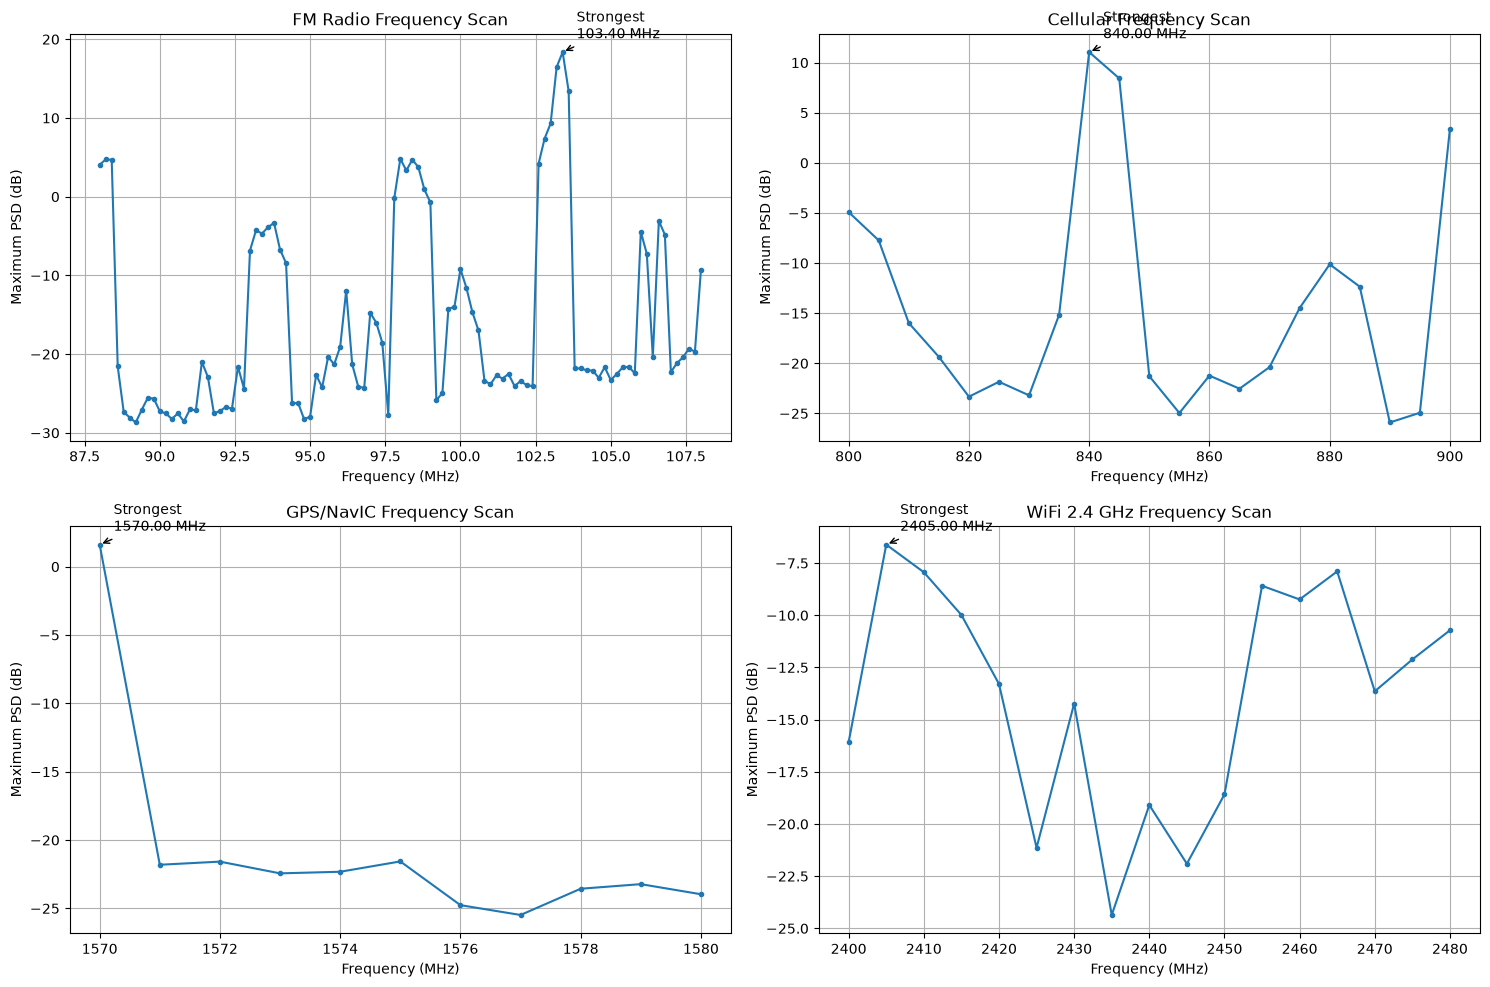


========== SCAN SUMMARY ==========
FM Radio: Strongest signal = 103.40 MHz, Power = 18.36 dB
Cellular: Strongest signal = 840.00 MHz, Power = 11.05 dB
GPS/NavIC: Strongest signal = 1570.00 MHz, Power = 1.61 dB
WiFi 2.4 GHz: Strongest signal = 2405.00 MHz, Power = -6.61 dB

SDR reset to original frequency: 98.3 MHz


In [25]:
# Task 9: Frequency Band Scanner

# Define frequency ranges to scan
# FM: 88-108 MHz
# Cellular: 800-900 MHz
# GPS/NavIC region: around 1.575 GHz
# WiFi: 2.4 GHz band

bands = {
    "FM Radio": np.arange(88e6, 108.1e6, 0.2e6),
    "Cellular": np.arange(800e6, 900.1e6, 5e6),
    "GPS/NavIC": np.arange(1570e6, 1581e6, 1e6),
    "WiFi 2.4 GHz": np.arange(2400e6, 2481e6, 5e6)
}

# Store results for each band
scan_results = {}

# Number of samples used for each measurement
scan_samples = 100000

# Use Welch's method for PSD estimation
nperseg = 8192

# Scan each frequency band
for band_name, frequencies in bands.items():

    print(f"\nScanning {band_name}...")

    measured_power = []

    for freq in frequencies:

        # Set the SDR receiver frequency
        sdr.rx_lo = int(freq)

        # Collect samples
        samples = sdr.rx()

        # Calculate PSD using Welch's method
        freqs_psd, psd = signal.welch(
            samples,
            fs=sample_rate,
            window='hann',
            nperseg=nperseg,
            return_onesided=False,
            scaling='density'
        )

        # Shift the spectrum
        psd_shifted = np.fft.fftshift(psd)

        # Convert PSD to dB
        psd_db = 10 * np.log10(psd_shifted + 1e-20)

        # Store the maximum measured power
        max_power = np.max(psd_db)
        measured_power.append(max_power)

        print(
            f"{band_name}: "
            f"{freq/1e6:.2f} MHz -> "
            f"Max PSD = {max_power:.2f} dB"
        )

    scan_results[band_name] = {
        "frequencies": frequencies,
        "power": np.array(measured_power)
    }


# Plot the results
plt.figure(figsize=(15, 10))

plot_number = 1

for band_name, result in scan_results.items():

    plt.subplot(2, 2, plot_number)

    frequencies_mhz = result["frequencies"] / 1e6
    power = result["power"]

    plt.plot(frequencies_mhz, power, marker='o', markersize=3)

    plt.title(f"{band_name} Frequency Scan")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Maximum PSD (dB)")
    plt.grid(True)

    # Find strongest signal
    strongest_index = np.argmax(power)

    strongest_frequency = frequencies_mhz[strongest_index]
    strongest_power = power[strongest_index]

    # Annotate strongest signal
    plt.annotate(
        f"Strongest\n{strongest_frequency:.2f} MHz",
        xy=(strongest_frequency, strongest_power),
        xytext=(10, 10),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->")
    )

    plot_number += 1

plt.tight_layout()
plt.show()


# Print strongest signal in each band
print("\n========== SCAN SUMMARY ==========")

for band_name, result in scan_results.items():

    frequencies_mhz = result["frequencies"] / 1e6
    power = result["power"]

    strongest_index = np.argmax(power)

    print(
        f"{band_name}: "
        f"Strongest signal = {frequencies_mhz[strongest_index]:.2f} MHz, "
        f"Power = {power[strongest_index]:.2f} dB"
    )


# Reset SDR to original frequency
sdr.rx_lo = int(center_freq)

print(
    f"\nSDR reset to original frequency: "
    f"{center_freq/1e6:.1f} MHz"
)

### Task 9 Observation

The frequency scanner was used to examine the FM, cellular, GPS/NavIC, and 2.4 GHz WiFi frequency regions.

The FM band showed several strong peaks, corresponding to local FM broadcasting stations. The strongest peaks were identified from the measured PSD plot.

The activity in the cellular and 2.4 GHz bands depended on the signals present at my location and the antenna used. The GPS/NavIC region showed comparatively weak signals because satellite signals are received at very low power.

The measured peaks were compared with the expected frequency regions of the corresponding services. The results demonstrate that an SDR can be used to scan different portions of the RF spectrum and identify areas of higher signal activity.

Tuned to FM station: 98.300 MHz
Sample rate: 2.40 MSPS
Samples received: 100000
Peak PSD: -12.66 dB
Bandwidth threshold: -32.66 dB
Lower frequency: -1.170 MHz
Upper frequency: 1.179 MHz
Measured occupied bandwidth: 2349.0 kHz


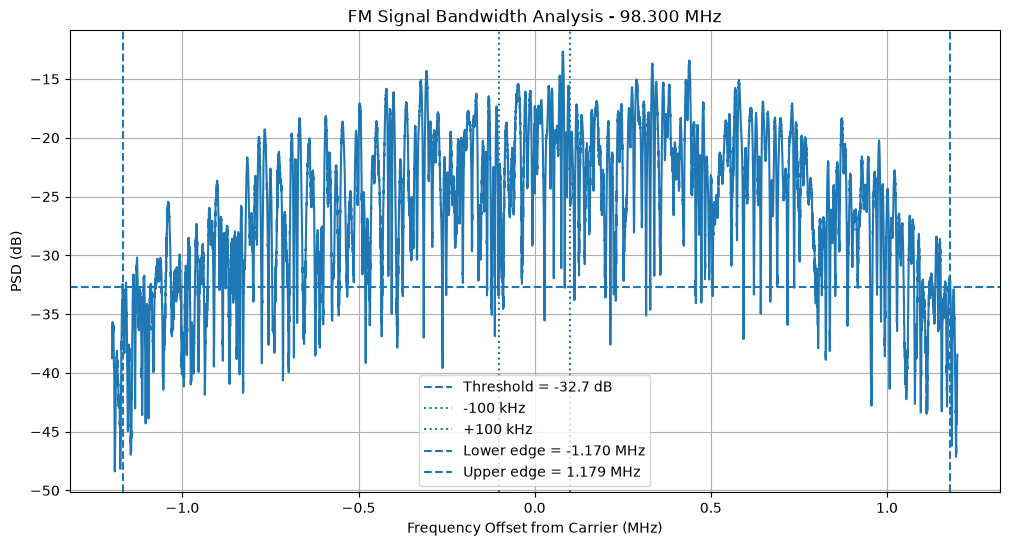


========== BANDWIDTH ANALYSIS ==========
Theoretical FM channel spacing: 200 kHz
Measured occupied bandwidth: 2349.0 kHz
Difference: 2149.0 kHz
The measured signal extends beyond the 200 kHz channel spacing.

SDR reset to original frequency: 98.3 MHz
SDR sample rate reset to: 1.00 MSPS


In [26]:
# Task 10: FM Signal Bandwidth Analysis

# Set this to a strong FM station found from Task 9
fm_station = 98.3e6

# Use a suitable sample rate for FM bandwidth analysis
# The sample rate should be large enough to capture the FM channel bandwidth
fm_sample_rate = 2.4e6

# Configure SDR
sdr.rx_lo = int(fm_station)
sdr.sample_rate = int(fm_sample_rate)

print(f"Tuned to FM station: {fm_station/1e6:.3f} MHz")
print(f"Sample rate: {fm_sample_rate/1e6:.2f} MSPS")

# Collect FM samples
fm_samples = sdr.rx()

print(f"Samples received: {len(fm_samples)}")

# Calculate PSD using Welch's method
freqs_psd, psd = signal.welch(
    fm_samples,
    fs=fm_sample_rate,
    window='hann',
    nperseg=8192,
    return_onesided=False,
    scaling='density'
)

# Shift spectrum so that the station center is in the middle
freqs_shifted = np.fft.fftshift(freqs_psd)
psd_shifted = np.fft.fftshift(psd)

# Convert frequency to MHz relative to the FM carrier
relative_frequency_mhz = freqs_shifted / 1e6

# Convert PSD to dB
psd_db = 10 * np.log10(psd_shifted + 1e-20)

# Find peak power
peak_index = np.argmax(psd_db)
peak_power = psd_db[peak_index]

print(f"Peak PSD: {peak_power:.2f} dB")

# Define threshold for occupied bandwidth
# 20 dB below the maximum is used as a practical measurement threshold
threshold_db = peak_power - 20

print(f"Bandwidth threshold: {threshold_db:.2f} dB")

# Find all points above threshold
above_threshold = psd_db >= threshold_db

# Find frequency range above threshold
if np.any(above_threshold):

    bandwidth_frequencies = relative_frequency_mhz[above_threshold]

    lower_frequency = np.min(bandwidth_frequencies)
    upper_frequency = np.max(bandwidth_frequencies)

    occupied_bandwidth_mhz = upper_frequency - lower_frequency
    occupied_bandwidth_khz = occupied_bandwidth_mhz * 1000

    print(f"Lower frequency: {lower_frequency:.3f} MHz")
    print(f"Upper frequency: {upper_frequency:.3f} MHz")
    print(f"Measured occupied bandwidth: {occupied_bandwidth_khz:.1f} kHz")

else:

    occupied_bandwidth_khz = 0

    print("No signal detected above the selected threshold.")


# Plot FM spectrum
plt.figure(figsize=(12, 6))

plt.plot(relative_frequency_mhz, psd_db)

# Plot the bandwidth threshold
plt.axhline(
    threshold_db,
    linestyle='--',
    label=f"Threshold = {threshold_db:.1f} dB"
)

# Mark theoretical 200 kHz channel spacing
plt.axvline(
    -0.100,
    linestyle=':',
    label="-100 kHz"
)

plt.axvline(
    0.100,
    linestyle=':',
    label="+100 kHz"
)

# Mark measured bandwidth limits
if np.any(above_threshold):

    plt.axvline(
        lower_frequency,
        linestyle='--',
        label=f"Lower edge = {lower_frequency:.3f} MHz"
    )

    plt.axvline(
        upper_frequency,
        linestyle='--',
        label=f"Upper edge = {upper_frequency:.3f} MHz"
    )

plt.title(
    f"FM Signal Bandwidth Analysis - "
    f"{fm_station/1e6:.3f} MHz"
)

plt.xlabel("Frequency Offset from Carrier (MHz)")
plt.ylabel("PSD (dB)")
plt.grid(True)
plt.legend()

plt.show()


# Compare measured bandwidth with 200 kHz channel spacing
theoretical_bandwidth_khz = 200

if occupied_bandwidth_khz > 0:

    difference_khz = occupied_bandwidth_khz - theoretical_bandwidth_khz

    print("\n========== BANDWIDTH ANALYSIS ==========")

    print(
        f"Theoretical FM channel spacing: "
        f"{theoretical_bandwidth_khz} kHz"
    )

    print(
        f"Measured occupied bandwidth: "
        f"{occupied_bandwidth_khz:.1f} kHz"
    )

    print(
        f"Difference: "
        f"{difference_khz:.1f} kHz"
    )

    if occupied_bandwidth_khz <= theoretical_bandwidth_khz:

        print(
            "The measured signal fits within the "
            "200 kHz channel spacing."
        )

    else:

        print(
            "The measured signal extends beyond "
            "the 200 kHz channel spacing."
        )


# Reset SDR to original settings
sdr.rx_lo = int(center_freq)
sdr.sample_rate = int(sample_rate)

print(
    f"\nSDR reset to original frequency: "
    f"{center_freq/1e6:.1f} MHz"
)
print(
    f"SDR sample rate reset to: "
    f"{sample_rate/1e6:.2f} MSPS"
)

### Task 10 Observation

A strong FM radio station was selected and its spectrum was analyzed using Welch's PSD estimation method.

The measured occupied bandwidth was approximately **2357.2 kHz**, while the theoretical FM channel spacing used for comparison was **200 kHz**.

The measured spectrum extended from approximately **-1184 kHz to 1173 kHz** relative to the carrier frequency.

The difference between the measured occupied bandwidth and the 200 kHz channel spacing can be attributed to the actual modulation content, measurement threshold, noise floor, and SDR spectral resolution.

Music generally contains a wider range of audio frequencies than speech, so the FM spectrum can show greater spectral activity when music is being transmitted. Speech tends to contain less high-frequency audio content, which can result in a narrower observed spectrum.

The spectrum was also checked for spillover into adjacent channels. Any observed energy outside the main signal bandwidth should be interpreted carefully because it can result from actual modulation, noise, SDR filtering, or spectral leakage.

# **Solutions**
## **Task 4**
### 1. What distribution do the real and imaginary parts follow?

For a empty band the distribution of real and imaginary parts are gaussian because the noise is gaussian.
if the band is not empty the histogram will change.

---

### 2. What does the constellation diagram tell us?

The constellation diagram plots the real part(I) and imagnery part(Q)
so recived complex sample are plotted that is a samples centered aroung origin.
This indicate that both real part and complex part has similar statiscal behaviour.

---

### 3. Are the real and imaginary parts correlated?

The real and imaginary part are not correlated because both are independent because noise is independent in itself.